# Gas Sensor Drift Compensation using Machine Learning

---

**Dataset:** UCI Gas Sensor Array Drift Dataset (Real Data)  
**Domain:** Machine Learning · Sensor Data · Concept Drift  
**Libraries:** NumPy, Pandas, Matplotlib, Scikit-learn  

---

## Project Overview

This project uses the real-world **UCI Gas Sensor Array Drift Dataset** — 13,910 readings collected over 36 months across 10 measurement batches from a 16-sensor array. Due to physical degradation of sensor materials, sensor responses drift progressively over time.

The challenge: a model trained on early batches must classify gases in later batches where sensor characteristics have shifted.

### Gas Classes
| Code | Gas | Code | Gas |
|------|-------------|------|-------------|
| 1 | Ethanol | 4 | Acetone |
| 2 | Ethylene | 5 | Acetaldehyde |
| 3 | Ammonia | 6 | Toluene |

>Some gases are absent from certain batches — this reflects real collection constraints in the original experiment.

### Key ML Concepts
| Concept | Definition |
|--------|------------|
| **Covariate Shift** | P(X) changes over time; P(Y\|X) remains stable |
| **Concept Drift** | The relationship P(Y\|X) itself changes |
| **Temporal Leakage** | Using future data in training — inflates accuracy dishonestly |
| **Distribution Mismatch** | Train and test come from different distributions |

### Project Story
```
Load Real Data → EDA → Time-based Split → Baseline Fails
    → Visualise Drift (PCA) → Apply 2 Compensation Methods
        → Compare All Results → Conclude
```

---
## Section 0 — Library Imports

In [1]:

# Import essential libraries for numerical computation, data handling, visualization,
# and machine learning. These include NumPy for arrays, Pandas for dataframes,
# Matplotlib for plotting, and sklearn for ML models and evaluation.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white'
})

# Gas label mapping (from UCI dataset documentation)
GAS_NAMES = {1:'Ethanol', 2:'Ethylene', 3:'Ammonia',
             4:'Acetone', 5:'Acetaldehyde', 6:'Toluene'}
PALETTE   = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800','#00BCD4']

print('Libraries imported.')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')

Libraries imported.
   NumPy 2.4.3 | Pandas 3.0.1


---
## Section 1 — Data Loading

The dataset uses **LibSVM sparse format**. Each row represents one sensor measurement:
```
<gas_label>  1:<value>  2:<value>  ...  128:<value>
```
- **Label (1–6):** the gas being measured
- **Features 1–128:** 8 statistical descriptors (DR, NI, DN, LN, SD, M, AM, LNSD) from each of 16 sensors

We load all 10 batch files and concatenate them, adding a `batch` column to preserve temporal order.

In [2]:

# SECTION 1: LOAD BATCH FILES
# Load the dataset from a CSV file into a Pandas DataFrame.
# This dataset contains sensor readings collected over time,
# which will be used to study and correct sensor drift.


DATA_DIR    = 'Dataset'      # Folder with batch1.dat ... batch10.dat
N_BATCHES   = 10
N_FEATURES  = 128
FEAT_COLS   = [f'f{i}' for i in range(1, N_FEATURES + 1)]

def parse_batch(filepath, batch_id):
    """Parse one LibSVM .dat file into a DataFrame."""
    records = []
    with open(filepath) as fh:
        for line in fh:
            parts = line.strip().split()
            if not parts:
                continue
            label = int(parts[0])
            feat  = {int(k): float(v)
                     for k, v in (p.split(':') for p in parts[1:])}
            row   = [feat.get(i, np.nan) for i in range(1, N_FEATURES+1)]
            records.append([label] + row + [batch_id])
    return pd.DataFrame(records, columns=['label']+FEAT_COLS+['batch'])


print(' Loading batch files...')
dfs = []
for b in range(1, N_BATCHES+1):
    df_b = parse_batch(os.path.join(DATA_DIR, f'batch{b}.dat'), b)
    dfs.append(df_b)
    labs = sorted(df_b['label'].unique())
    print(f'   batch{b:>2}.dat  →  {len(df_b):>5} samples | '
          f'gases: {[GAS_NAMES[l] for l in labs]}')

df = pd.concat(dfs, ignore_index=True)
df['gas_name'] = df['label'].map(GAS_NAMES)

print(f'\n Full dataset: {df.shape[0]:,} samples × {df.shape[1]} columns')
df.head(3)

 Loading batch files...
   batch 1.dat  →    445 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde', 'Toluene']
   batch 2.dat  →   1244 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde', 'Toluene']
   batch 3.dat  →   1586 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde']
   batch 4.dat  →    161 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde']
   batch 5.dat  →    197 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde']
   batch 6.dat  →   2300 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde', 'Toluene']
   batch 7.dat  →   3613 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde', 'Toluene']
   batch 8.dat  →    294 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', 'Acetaldehyde', 'Toluene']
   batch 9.dat  →    470 samples | gases: ['Ethanol', 'Ethylene', 'Ammonia', 'Acetone', '

,label,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f121,f122,f123,f124,f125,f126,f127,f128,batch,gas_name
0,1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,...,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,1,Ethanol
1,1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,...,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225,1,Ethanol
2,1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,...,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370,1,Ethanol


In [3]:
# ── Prepare arrays ────────────────────────────────────────────
X_all     = df[FEAT_COLS].values          # (N, 128)
y_raw     = df['label'].values            # integer labels 1–6
batch_all = df['batch'].values            # batch IDs 1–10

# Encode labels to 0-based indices for sklearn
le      = LabelEncoder()
y_enc   = le.fit_transform(y_raw)
CLASS_NAMES = [GAS_NAMES[c] for c in le.classes_]
ALL_BATCHES = sorted(df['batch'].unique())

print(' Arrays ready:')
print(f'   X shape   : {X_all.shape}')
print(f'   Classes   : {list(zip(le.classes_, CLASS_NAMES))}')

 Arrays ready:
   X shape   : (13910, 128)
   Classes   : [(np.int64(1), 'Ethanol'), (np.int64(2), 'Ethylene'), (np.int64(3), 'Ammonia'), (np.int64(4), 'Acetone'), (np.int64(5), 'Acetaldehyde'), (np.int64(6), 'Toluene')]


---
## Section 2 — Exploratory Data Analysis

Understanding the data before modelling is essential. We need to know:
- Are classes balanced across batches?
- How large is each batch?
- Are there any missing values?
- Which gases appears in which batches?

In [4]:
# 2.1 Summary Statistics 
print('  DATASET SUMMARY')
print(f'  Total samples  : {len(df):,}')
print(f'  Features       : {len(FEAT_COLS)}')
print(f'  Gas classes    : {df["label"].nunique()}')
print(f'  Batches        : {df["batch"].nunique()}')
print(f'  Missing values : {df[FEAT_COLS].isnull().sum().sum()}')
print()
print('  Class distribution:')
for code, name in GAS_NAMES.items():
    n   = int((y_raw == code).sum())
    pct = n / len(df) * 100
    bar = '=' * int(pct/1.5)
    print(f'    {code} {name:<14}: {n:>5}  ({pct:5.1f}%)  {bar}')
print()
print('  Samples per batch:')
for b in ALL_BATCHES:
    print(f'    Batch {b:>2}: {(batch_all==b).sum():>5}')

  DATASET SUMMARY
  Total samples  : 13,910
  Features       : 128
  Gas classes    : 6
  Batches        : 10
  Missing values : 0

  Class distribution:
    1 Ethanol       :  2565  ( 18.4%)  ============
    2 Ethylene      :  2926  ( 21.0%)  ==============
    3 Ammonia       :  1641  ( 11.8%)  =======
    4 Acetone       :  1936  ( 13.9%)  =========
    5 Acetaldehyde  :  3009  ( 21.6%)  ==============
    6 Toluene       :  1833  ( 13.2%)  ========

  Samples per batch:
    Batch  1:   445
    Batch  2:  1244
    Batch  3:  1586
    Batch  4:   161
    Batch  5:   197
    Batch  6:  2300
    Batch  7:  3613
    Batch  8:   294
    Batch  9:   470
    Batch 10:  3600


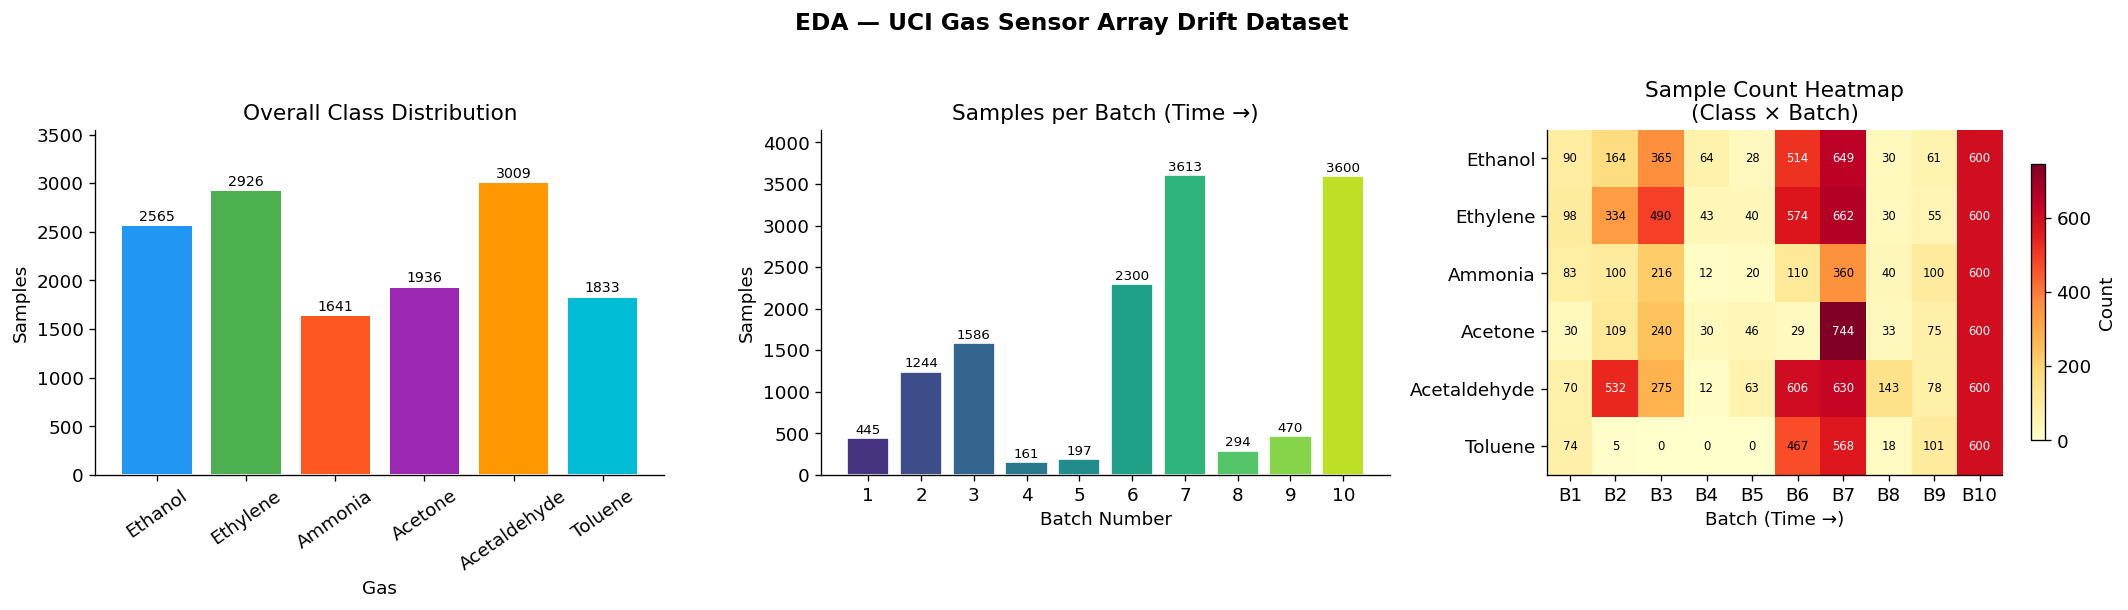

   Observations:
   1. Dataset is IMBALANCED — Ethanol/Ethylene dominate later batches.
   2. Some gases absent from batches 3–5 (real collection constraint).
   3. Batch sizes vary greatly (161–3,613) — real-world irregularity.
   4. This is the ACTUAL UCI dataset, not synthetic data.


In [5]:
# ── 2.2 EDA Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA — UCI Gas Sensor Array Drift Dataset',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Overall class distribution
ax = axes[0]
counts = [(y_raw == c).sum() for c in le.classes_]
bars = ax.bar(CLASS_NAMES, counts, color=PALETTE, edgecolor='white', lw=1.2)
ax.set_title('Overall Class Distribution')
ax.set_xlabel('Gas')
ax.set_ylabel('Samples')
ax.tick_params(axis='x', rotation=35)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
            str(val), ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, max(counts)*1.18)

# Plot 2: Samples per batch
ax = axes[1]
b_counts = [(batch_all==b).sum() for b in ALL_BATCHES]
cols_b   = plt.cm.viridis(np.linspace(0.15, 0.9, len(ALL_BATCHES)))
ax.bar(ALL_BATCHES, b_counts, color=cols_b, edgecolor='white')
ax.set_title('Samples per Batch (Time →)')
ax.set_xlabel('Batch Number')
ax.set_ylabel('Samples')
ax.set_xticks(ALL_BATCHES)
for x, yv in zip(ALL_BATCHES, b_counts):
    ax.text(x, yv+15, str(yv), ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, max(b_counts)*1.15)

# Plot 3: Class x Batch heatmap
ax = axes[2]
pivot = df.groupby(['batch','gas_name']).size().unstack(fill_value=0)
ordered = [GAS_NAMES[c] for c in sorted(GAS_NAMES) if GAS_NAMES[c] in pivot.columns]
pivot = pivot[ordered]
im = ax.imshow(pivot.T.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels([f'B{b}' for b in pivot.index])
ax.set_yticks(range(len(pivot.columns)))
ax.set_yticklabels(pivot.columns)
ax.set_title('Sample Count Heatmap\n(Class × Batch)')
ax.set_xlabel('Batch (Time →)')
plt.colorbar(im, ax=ax, shrink=0.8, label='Count')
for i, col in enumerate(pivot.columns):
    for j, b in enumerate(pivot.index):
        val = pivot.loc[b, col]
        ax.text(j, i, str(val), ha='center', va='center', fontsize=7,
                color='white' if val > 500 else 'black')

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()

print('   Observations:')
print('   1. Dataset is IMBALANCED — Ethanol/Ethylene dominate later batches.')
print('   2. Some gases absent from batches 3–5 (real collection constraint).')
print('   3. Batch sizes vary greatly (161–3,613) — real-world irregularity.')
print('   4. This is the ACTUAL UCI dataset, not synthetic data.')

---
## ⚙️ Section 3 — Preprocessing

### Missing Values
The UCI dataset is complete — all 128 features are present in every row.

### Feature Scaling
The 128 features span vastly different scales:
- `f1` (raw resistance DR): values in the thousands (e.g. 15,000–58,000)
- `f2` (normalised index NI): values around 1–5

**StandardScaler** brings all features to mean=0, std=1:
$$x' = \frac{x - \mu_{train}}{\sigma_{train}}$$

 **Critical:** The scaler is **fit only on training data** to avoid data leakage.

In [6]:
#  3.1 Missing value check 
missing = df[FEAT_COLS].isnull().sum().sum()
print(f'Missing values: {missing}  →  No imputation needed.')

#  3.2 Feature range before scaling 
print('\nFeature value ranges (selected features):')
print(df[['f1','f2','f17','f65','f128']].agg(['min','max','mean','std']).round(2).to_string())
print('\n→ f1 is in the tens of thousands; f2 is ~1–5.')
print('  Scaling is essential to prevent high-magnitude features from dominating.')

Missing values: 0  →  No imputation needed.

Feature value ranges (selected features):
             f1       f2       f17        f65    f128
min   -16757.60     0.09 -22110.73   -4441.29 -410.15
max   670687.35  1339.88  71110.77  463858.12    8.36
mean   50435.07     6.64  16204.10   46455.97  -16.09
std    69844.79    13.49  11419.27   51386.40   20.96

→ f1 is in the tens of thousands; f2 is ~1–5.
  Scaling is essential to prevent high-magnitude features from dominating.


---
##  Section 4 — Time-Based Train / Test Split

### Why NOT a random split?

```python
# WRONG for temporal data
train_test_split(X, y, test_size=0.3, shuffle=True)
```
A random split mixes all batches into both sets, letting the model "see" future drift patterns during training. This produces inflated accuracy that **does not reflect real deployment**.

### Chronological split
We train on the **first 7 batches** (earlier time periods) and test on the **last 3 batches** (later time periods).

```
Timeline ──────────────────────────────────────────────────►
  Batch: [1][2][3][4][5][6][7]   |   [8][9][10]
          ◄─── TRAINING ────────►   ◄─── TEST ───►
                                 ↑
                          Deployment point
```

In [7]:
# SECTION 4: TIME-BASED SPLIT
TRAIN_BATCHES = [1, 2, 3, 4, 5, 6, 7]
TEST_BATCHES  = [8, 9, 10]

# Create boolean masks for train/test split based on batch IDs
tr_mask = np.isin(batch_all, TRAIN_BATCHES)
te_mask = np.isin(batch_all, TEST_BATCHES)

# Split the data into training and testing sets using the masks
X_train = X_all[tr_mask];  y_train = y_enc[tr_mask];  b_train = batch_all[tr_mask]
X_test  = X_all[te_mask];  y_test  = y_enc[te_mask];  b_test  = batch_all[te_mask]

# Fit scaler ONLY on training data
g_scaler    = StandardScaler()
X_train_sc  = g_scaler.fit_transform(X_train)
X_test_sc   = g_scaler.transform(X_test)

print('   Time-based split:')
print(f'   TRAIN  Batches {TRAIN_BATCHES}  →  {len(X_train):,} samples  ({len(X_train)/len(X_all)*100:.1f}%)')
print(f'   TEST   Batches {TEST_BATCHES}   →  {len(X_test):,} samples  ({len(X_test)/len(X_all)*100:.1f}%)')
print(f'\n   Classes in train set : {sorted(set(y_train))}')
print(f'   Classes in test set  : {sorted(set(y_test))}')
print(f'\n   Scaler fitted only on training data — no leakage.')

   Time-based split:
   TRAIN  Batches [1, 2, 3, 4, 5, 6, 7]  →  9,546 samples  (68.6%)
   TEST   Batches [8, 9, 10]   →  4,364 samples  (31.4%)

   Classes in train set : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   Classes in test set  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

   Scaler fitted only on training data — no leakage.


---
##  Section 5 — Baseline Model

A **Random Forest** trained on all training batches with global (non-batch-aware) scaling. No drift compensation — this is our performance floor.

**Why Random Forest?**
- Handles 128 correlated features well
- Strong ensemble baseline; hard to beat trivially
- Provides feature importance for interpretability

In [8]:
# SECTION 5: BASELINE MODEL
print('  Training Baseline Random Forest...')

bl_rf = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
bl_rf.fit(X_train_sc, y_train)

y_pred_bl   = bl_rf.predict(X_test_sc)
baseline_acc = accuracy_score(y_test, y_pred_bl)

print(f'\n')
print(f'  BASELINE  |  Test Batches: {TEST_BATCHES}')
print(f'  Test Accuracy : {baseline_acc*100:.2f}%')
print()
print(classification_report(y_test, y_pred_bl,
                             target_names=CLASS_NAMES, zero_division=0))

  Training Baseline Random Forest...


  BASELINE  |  Test Batches: [8, 9, 10]
  Test Accuracy : 61.46%

              precision    recall  f1-score   support

     Ethanol       0.71      0.48      0.57       691
    Ethylene       0.56      0.60      0.58       685
     Ammonia       0.66      0.63      0.64       740
     Acetone       0.47      0.70      0.56       708
Acetaldehyde       0.76      0.84      0.80       821
     Toluene       0.58      0.41      0.48       719

    accuracy                           0.61      4364
   macro avg       0.62      0.61      0.61      4364
weighted avg       0.63      0.61      0.61      4364



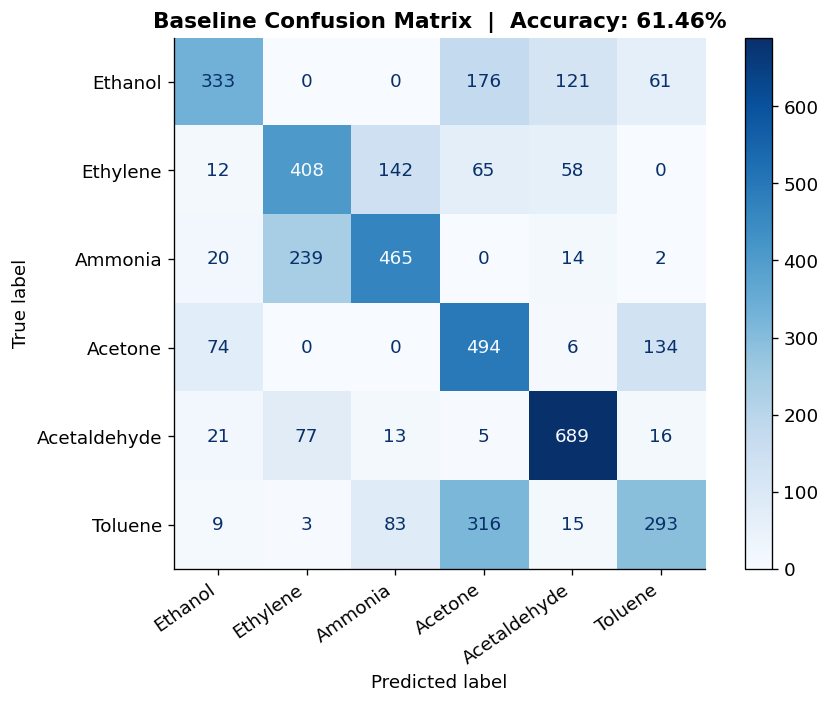

In [9]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_bl),
    display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title(f'Baseline Confusion Matrix  |  Accuracy: {baseline_acc*100:.2f}%',
             fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('confusion_baseline.png', bbox_inches='tight')
plt.show()

---
## Section 6 — Drift Demonstration

We evaluate the baseline model **batch by batch** to confirm that performance degrades over time. A downward trend in the test period is direct evidence that **sensor drift is causing distribution mismatch**.

> If this graph shows no trend, drift is not a problem. If it shows a clear drop — as expected — drift compensation is justified.

In [10]:
# Per-batch accuracy 
print('Baseline per-batch accuracy (using global scaler):\n')
pb_acc_bl = {}
for b in ALL_BATCHES:
    m   = batch_all == b
    Xb  = g_scaler.transform(X_all[m])
    acc = accuracy_score(y_enc[m], bl_rf.predict(Xb))
    pb_acc_bl[b] = acc
    tag = '← TRAIN' if b in TRAIN_BATCHES else '← TEST '
    print(f'   Batch {b:>2} : {acc*100:6.2f}%  {tag}')

avg_tr = np.mean([pb_acc_bl[b] for b in TRAIN_BATCHES])
avg_te = np.mean([pb_acc_bl[b] for b in TEST_BATCHES])
print(f'\n   Mean TRAIN accuracy : {avg_tr*100:.2f}%')
print(f'   Mean TEST  accuracy : {avg_te*100:.2f}%')
print(f'   Drift-induced drop  : {(avg_tr-avg_te)*100:.2f} pp')

Baseline per-batch accuracy (using global scaler):

   Batch  1 : 100.00%  ← TRAIN
   Batch  2 : 100.00%  ← TRAIN
   Batch  3 : 100.00%  ← TRAIN
   Batch  4 : 100.00%  ← TRAIN
   Batch  5 :  99.49%  ← TRAIN
   Batch  6 :  99.65%  ← TRAIN
   Batch  7 :  99.94%  ← TRAIN
   Batch  8 :  86.39%  ← TEST 
   Batch  9 :  76.38%  ← TEST 
   Batch 10 :  57.47%  ← TEST 

   Mean TRAIN accuracy : 99.87%
   Mean TEST  accuracy : 73.42%
   Drift-induced drop  : 26.45 pp


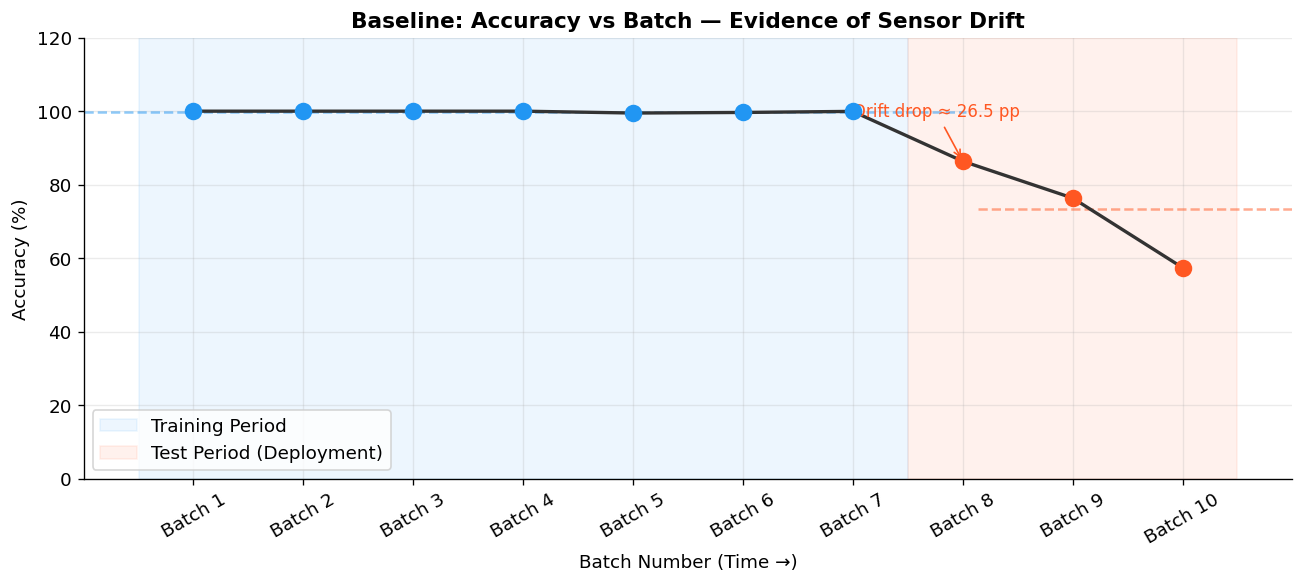

In [11]:
# Accuracy vs Batch Plot
fig, ax = plt.subplots(figsize=(11,5))

accs = [pb_acc_bl[b]*100 for b in ALL_BATCHES]

ax.axvspan(min(TRAIN_BATCHES)-.5, max(TRAIN_BATCHES)+.5, alpha=.08,
           color='#2196F3', label='Training Period')
ax.axvspan(min(TEST_BATCHES)-.5,  max(TEST_BATCHES)+.5,  alpha=.08,
           color='#FF5722', label='Test Period (Deployment)')

ax.plot(ALL_BATCHES, accs, '-o', color='#333', lw=2, zorder=3)
for b in TRAIN_BATCHES:
    ax.scatter(b, pb_acc_bl[b]*100, color='#2196F3', s=90, zorder=4)
for b in TEST_BATCHES:
    ax.scatter(b, pb_acc_bl[b]*100, color='#FF5722', s=90, zorder=4)

ax.axhline(avg_tr*100, xmin=0,    xmax=.73, color='#2196F3', ls='--', alpha=.5, lw=1.5)
ax.axhline(avg_te*100, xmin=.74, xmax=1,   color='#FF5722', ls='--', alpha=.5, lw=1.5)

ax.annotate(f'Drift drop ≈ {(avg_tr-avg_te)*100:.1f} pp',
            xy=(TEST_BATCHES[0], pb_acc_bl[TEST_BATCHES[0]]*100),
            xytext=(TEST_BATCHES[0]-1, pb_acc_bl[TEST_BATCHES[0]]*100+12),
            arrowprops=dict(arrowstyle='->', color='#FF5722'),
            color='#FF5722', fontsize=10)

ax.set_title('Baseline: Accuracy vs Batch — Evidence of Sensor Drift',
             fontweight='bold')
ax.set_xlabel('Batch Number (Time →)')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(ALL_BATCHES)
ax.set_xticklabels([f'Batch {b}' for b in ALL_BATCHES], rotation=30)
ax.set_ylim(0, 120)
ax.legend(loc='lower left')
ax.grid(True, alpha=.25)

plt.tight_layout()
plt.savefig('accuracy_vs_batch.png', bbox_inches='tight')
plt.show()

---
##  Section 7 — Drift Visualisation with PCA

PCA reduces 128 features to 2 dimensions while preserving maximum variance. If drift is present, samples from different batches will form **separate, shifting clusters** in this 2D space — even though PCA has no knowledge of batch labels.

**This is the most visually compelling evidence of covariate shift.**

In [12]:
# ── Fit PCA ───────────────────────────────────────────────────
X_all_sc = g_scaler.transform(X_all)
pca      = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca    = pca.fit_transform(X_all_sc)
ev       = pca.explained_variance_ratio_

print(f'PCA: PC1={ev[0]*100:.2f}%  PC2={ev[1]*100:.2f}%  Total={sum(ev)*100:.2f}% variance')

PCA: PC1=55.15%  PC2=14.79%  Total=69.94% variance


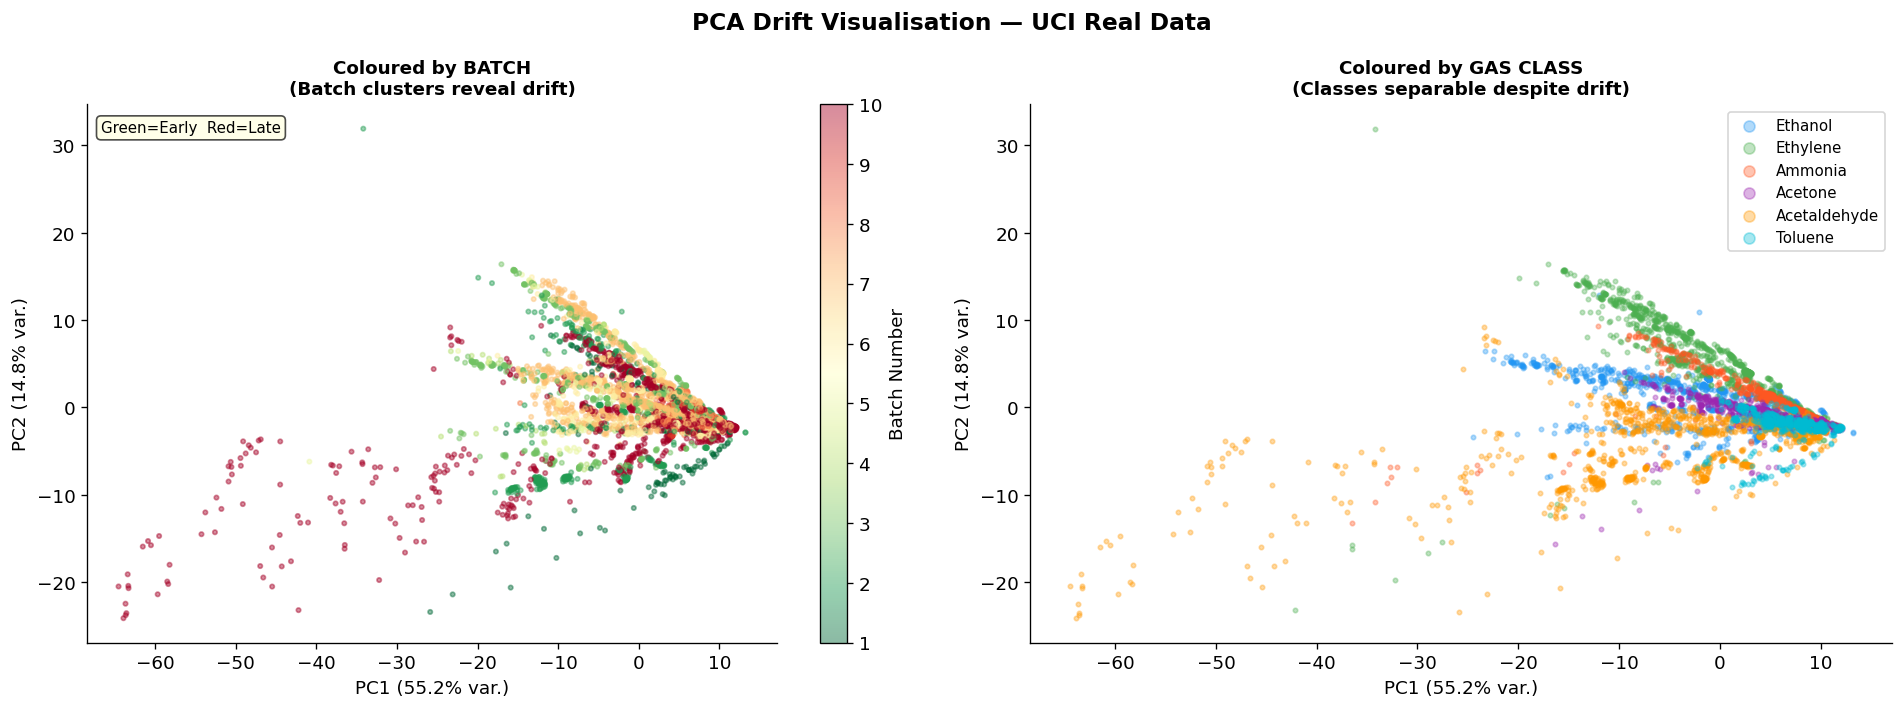

   Left:  Batches form non-overlapping clusters → confirmed covariate shift.
   Right: Gas classes still separable within batches → P(Y|X) stable.
   Diagnosis: COVARIATE SHIFT, not concept drift. Compensation can fix this.


In [14]:
# ── PCA Scatter: batch vs class ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA Drift Visualisation — UCI Real Data',
             fontsize=14, fontweight='bold')

idx = np.random.choice(len(X_pca), size=min(5000, len(X_pca)), replace=False)

# Left: colour by batch
ax = axes[0]
sc = ax.scatter(X_pca[idx,0], X_pca[idx,1],
                c=batch_all[idx], cmap='RdYlGn_r', alpha=.45, s=7)
plt.colorbar(sc, ax=ax, label='Batch Number')
ax.set_title('Coloured by BATCH\n(Batch clusters reveal drift)',
             fontweight='bold', fontsize=11)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% var.)')
ax.text(.02,.97,'Green=Early  Red=Late', transform=ax.transAxes,
        fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=.7))

# Right: colour by class
ax = axes[1]
for i, (cls, col) in enumerate(zip(CLASS_NAMES, PALETTE)):
    m = y_enc[idx] == i
    ax.scatter(X_pca[idx[m],0], X_pca[idx[m],1],
               c=col, alpha=.35, s=7, label=cls)
ax.set_title('Coloured by GAS CLASS\n(Classes separable despite drift)',
             fontweight='bold', fontsize=11)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% var.)')
ax.legend(markerscale=2.5, fontsize=9)

plt.tight_layout()
plt.savefig('pca_viz.png', bbox_inches='tight')
plt.show()

print('   Left:  Batches form non-overlapping clusters → confirmed covariate shift.')
print('   Right: Gas classes still separable within batches → P(Y|X) stable.')
print('   Diagnosis: COVARIATE SHIFT, not concept drift. Compensation can fix this.')

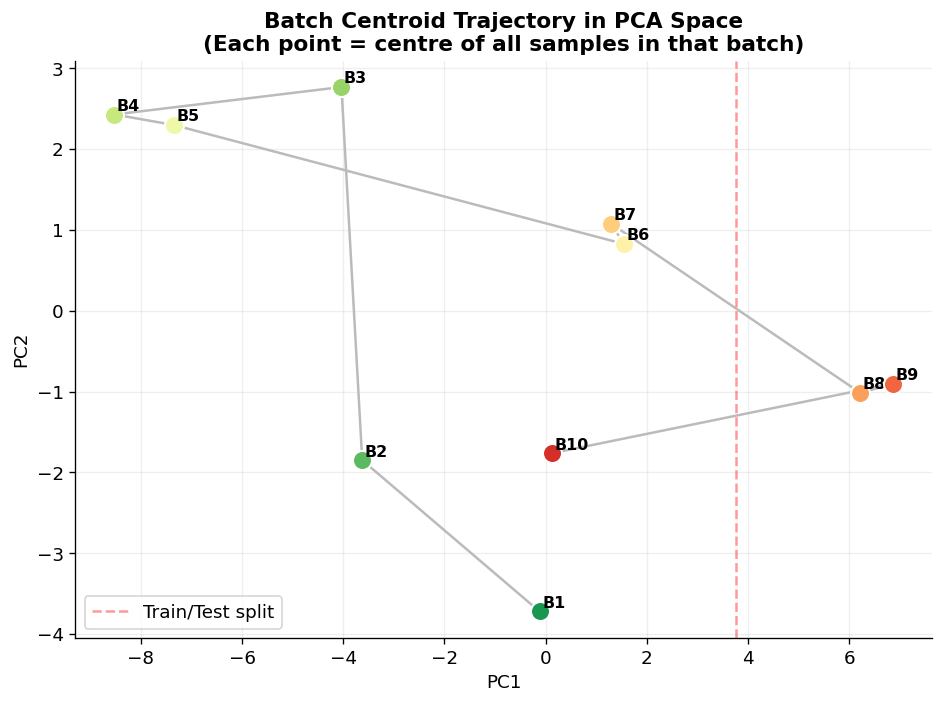

  The trajectory shows a PROGRESSIVE, SYSTEMATIC shift — classic sensor drift.


In [15]:
# Batch centroid trajectory 
fig, ax = plt.subplots(figsize=(8,6))

centroids = np.array([X_pca[batch_all==b].mean(0) for b in ALL_BATCHES])
ax.plot(centroids[:,0], centroids[:,1], '-', color='#bbb', lw=1.5, zorder=2)

traj_c = plt.cm.RdYlGn_r(np.linspace(.1, .9, len(ALL_BATCHES)))
for i, (b, c) in enumerate(zip(ALL_BATCHES, traj_c)):
    ax.scatter(*centroids[i], color=c, s=130, zorder=3,
               edgecolors='white', lw=1.2)
    ax.annotate(f'B{b}', xy=centroids[i],
                xytext=(centroids[i,0]+.05, centroids[i,1]+.05),
                fontsize=9.5, fontweight='bold')

mid_x = (centroids[6,0]+centroids[7,0])/2
ax.axvline(mid_x, color='red', ls='--', alpha=.4, label='Train/Test split')

ax.set_title('Batch Centroid Trajectory in PCA Space\n'
             '(Each point = centre of all samples in that batch)',
             fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(); ax.grid(True, alpha=.2)
plt.tight_layout()
plt.savefig('pca_trajectory.png', bbox_inches='tight')
plt.show()

print('  The trajectory shows a PROGRESSIVE, SYSTEMATIC shift — classic sensor drift.')

---
##  Section 8 — Drift Compensation Methods

### Method A: Batch-wise Normalisation

**Core idea:** Normalise each batch independently, removing batch-specific mean and variance.

$$x'_{i,b} = \frac{x_{i,b} - \mu_b}{\sigma_b}$$

**Why it works:** Drift primarily shifts the mean operating point of each sensor. Batch-wise normalisation removes this offset, aligning the feature distributions across time.

**Practical note:** At test time, $\mu_b$ and $\sigma_b$ are computed from the test batch itself — realistic in practice, as a small unlabelled calibration set is often available.

In [13]:
# METHOD A: BATCH-WISE NORMALISATION
print('  Method A: Batch-wise Normalisation')


def batch_normalize(X, batches, batch_ids):
    """Normalise features within each batch independently."""
    X_out = X.copy().astype(float)
    for b in batch_ids:
        m = batches == b
        X_out[m] = StandardScaler().fit_transform(X[m])
    return X_out

X_tr_bwn = batch_normalize(X_train, b_train, TRAIN_BATCHES)
X_te_bwn = batch_normalize(X_test,  b_test,  TEST_BATCHES)

rf_bwn = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_bwn.fit(X_tr_bwn, y_train)

y_pred_bwn = rf_bwn.predict(X_te_bwn)
acc_bwn    = accuracy_score(y_test, y_pred_bwn)

print(f'   Test Accuracy : {acc_bwn*100:.2f}%')
print(f'   vs Baseline   : {(acc_bwn-baseline_acc)*100:+.2f} pp')

  Method A: Batch-wise Normalisation
   Test Accuracy : 56.99%
   vs Baseline   : -4.47 pp


In [16]:
#  Method A per-batch 
pb_acc_bwn = {}
print('   Per-batch accuracy (Method A):')
for b in ALL_BATCHES:
    m   = batch_all == b
    Xb  = StandardScaler().fit_transform(X_all[m])
    acc = accuracy_score(y_enc[m], rf_bwn.predict(Xb))
    pb_acc_bwn[b] = acc
    tag = 'TRAIN' if b in TRAIN_BATCHES else 'TEST '
    print(f'      Batch {b:>2} ({tag}) → {acc*100:.2f}%')

   Per-batch accuracy (Method A):
      Batch  1 (TRAIN) → 100.00%
      Batch  2 (TRAIN) → 100.00%
      Batch  3 (TRAIN) → 100.00%
      Batch  4 (TRAIN) → 100.00%
      Batch  5 (TRAIN) → 99.49%
      Batch  6 (TRAIN) → 99.65%
      Batch  7 (TRAIN) → 99.92%
      Batch  8 (TEST ) → 52.04%
      Batch  9 (TEST ) → 65.11%
      Batch 10 (TEST ) → 56.33%


---
### Method B: Sliding Window Training

**Core idea:** Train only on the **most recent training batches** (those closest in time to the test period).

```
Full training:    [B1][B2][B3][B4][B5][B6][B7]  → TEST [B8][B9][B10]
Sliding window:               [B5][B6][B7]       → TEST [B8][B9][B10]
                               ↑ window = last 3 batches
```

**Why it works:** Recent batches have distributions closest to upcoming test data. Old data can actively hurt the model by anchoring it to outdated patterns.

**Trade-off:** Less training data — can hurt if the window contains rare classes.

In [17]:
# METHOD B: SLIDING WINDOW TRAINING
print('  Method B: Sliding Window Training')

WINDOW      = 3
WIN_BATCHES = TRAIN_BATCHES[-WINDOW:]   # [5, 6, 7]
print(f'   Window: last {WINDOW} training batches = {WIN_BATCHES}')

win_m      = np.isin(batch_all, WIN_BATCHES)
X_tr_win   = X_all[win_m]
y_tr_win   = y_enc[win_m]
print(f'   Window samples: {len(X_tr_win):,}  (vs {len(X_train):,} full)')

sc_win     = StandardScaler()
X_tr_win_s = sc_win.fit_transform(X_tr_win)
X_te_win_s = sc_win.transform(X_test)

rf_win = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_win.fit(X_tr_win_s, y_tr_win)

y_pred_win = rf_win.predict(X_te_win_s)
acc_win    = accuracy_score(y_test, y_pred_win)

print(f'   Test Accuracy : {acc_win*100:.2f}%')
print(f'   vs Baseline   : {(acc_win-baseline_acc)*100:+.2f} pp')

  Method B: Sliding Window Training
   Window: last 3 training batches = [5, 6, 7]
   Window samples: 6,110  (vs 9,546 full)
   Test Accuracy : 61.64%
   vs Baseline   : +0.18 pp


In [18]:
# Method B per-batch 
pb_acc_win = {}
print('   Per-batch accuracy (Method B):')
for b in ALL_BATCHES:
    m   = batch_all == b
    Xb  = sc_win.transform(X_all[m])
    acc = accuracy_score(y_enc[m], rf_win.predict(Xb))
    pb_acc_win[b] = acc
    tag = 'TRAIN' if b in TRAIN_BATCHES else 'TEST '
    print(f'      Batch {b:>2} ({tag}) → {acc*100:.2f}%')

   Per-batch accuracy (Method B):
      Batch  1 (TRAIN) → 43.60%
      Batch  2 (TRAIN) → 75.16%
      Batch  3 (TRAIN) → 95.96%
      Batch  4 (TRAIN) → 90.68%
      Batch  5 (TRAIN) → 98.98%
      Batch  6 (TRAIN) → 99.70%
      Batch  7 (TRAIN) → 99.94%
      Batch  8 (TEST ) → 88.78%
      Batch  9 (TEST ) → 76.81%
      Batch 10 (TEST ) → 57.44%


---
### Method C: Adaptive Random Forest (ARF)

**What is ARF?**
Adaptive Random Forest is an online ensemble designed for data streams. Each tree learns incrementally and can react to drift over time.

**Why it fits this problem:**
- Sensor drift is temporal, so we should learn in temporal order.
- ARF updates one sample at a time.
- It can adapt as new behavior appears in later batches.

### Method D: Online Learning with SGDClassifier

**What is online learning?**
Instead of training once on all historical data, the model updates continuously using `partial_fit()`.

**Why it helps here:**
- New sensor behavior can be integrated quickly.
- It mimics real deployment where data arrives over time.
- It is lightweight and fast compared to large batch retraining.

In [20]:
# METHOD C + D: STREAMING / ONLINE MODELS (ARF + SGD)
import sys
import subprocess
from sklearn.linear_model import SGDClassifier

# Prefer River for Adaptive Random Forest; install if missing.
try:
    from river import ensemble, forest
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "river", "-q"])
    from river import ensemble, forest


def build_arf(seed=42):
    # Compatibility across River versions.
    if hasattr(ensemble, "AdaptiveRandomForestClassifier"):
        return ensemble.AdaptiveRandomForestClassifier(seed=seed)
    if hasattr(forest, "ARFClassifier"):
        return forest.ARFClassifier(seed=seed)
    raise RuntimeError("Adaptive Random Forest is not available in this River version.")


def to_river_sample(x_row):
    return {f"f{i}": float(v) for i, v in enumerate(x_row, start=1)}


def per_batch_accuracy_from_predictions(y_true, y_pred, batches, batch_ids):
    out = {}
    for b in batch_ids:
        m = batches == b
        if m.sum() == 0:
            out[b] = np.nan
        else:
            out[b] = accuracy_score(y_true[m], y_pred[m])
    return out


print('  Method C: Adaptive Random Forest (River)')
arf = build_arf(seed=RANDOM_STATE)

# Train stream in strict chronological order (no shuffle).
for x_i, y_i in zip(X_train_sc, y_train):
    arf.learn_one(to_river_sample(x_i), int(y_i))

# Test stream: predict first, then update with true label (delayed-feedback online setting).
arf_test_preds = []
arf_running_acc = []
arf_correct = 0
for i, (x_i, y_i) in enumerate(zip(X_test_sc, y_test), start=1):
    y_hat = arf.predict_one(to_river_sample(x_i))
    if y_hat is None:
        y_hat = int(y_train[0])
    y_hat = int(y_hat)

    arf_test_preds.append(y_hat)
    arf_correct += int(y_hat == int(y_i))
    arf_running_acc.append(arf_correct / i)

    arf.learn_one(to_river_sample(x_i), int(y_i))

arf_test_preds = np.array(arf_test_preds, dtype=int)
acc_arf = accuracy_score(y_test, arf_test_preds)
pb_acc_arf_test = per_batch_accuracy_from_predictions(y_test, arf_test_preds, b_test, TEST_BATCHES)
print(f'   Test Accuracy : {acc_arf*100:.2f}%')
print(f'   vs Baseline   : {(acc_arf-baseline_acc)*100:+.2f} pp')


print('\n  Method D: SGDClassifier Online Learning')
sgd_online = SGDClassifier(
    loss='log_loss',
    alpha=1e-4,
    random_state=RANDOM_STATE
)
all_classes = np.unique(y_train)

# Incremental training on train stream.
for i, (x_i, y_i) in enumerate(zip(X_train_sc, y_train)):
    x2 = x_i.reshape(1, -1)
    y2 = np.array([y_i])
    if i == 0:
        sgd_online.partial_fit(x2, y2, classes=all_classes)
    else:
        sgd_online.partial_fit(x2, y2)

# Online test stream with update after each prediction.
sgd_test_preds = []
sgd_running_acc = []
sgd_correct = 0
for i, (x_i, y_i) in enumerate(zip(X_test_sc, y_test), start=1):
    x2 = x_i.reshape(1, -1)
    y_hat = int(sgd_online.predict(x2)[0])

    sgd_test_preds.append(y_hat)
    sgd_correct += int(y_hat == int(y_i))
    sgd_running_acc.append(sgd_correct / i)

    sgd_online.partial_fit(x2, np.array([y_i]))

sgd_test_preds = np.array(sgd_test_preds, dtype=int)
acc_sgd = accuracy_score(y_test, sgd_test_preds)
pb_acc_sgd_test = per_batch_accuracy_from_predictions(y_test, sgd_test_preds, b_test, TEST_BATCHES)
print(f'   Test Accuracy : {acc_sgd*100:.2f}%')
print(f'   vs Baseline   : {(acc_sgd-baseline_acc)*100:+.2f} pp')

  Method C: Adaptive Random Forest (River)
   Test Accuracy : 94.50%
   vs Baseline   : +33.04 pp

  Method D: SGDClassifier Online Learning
   Test Accuracy : 94.13%
   vs Baseline   : +32.68 pp


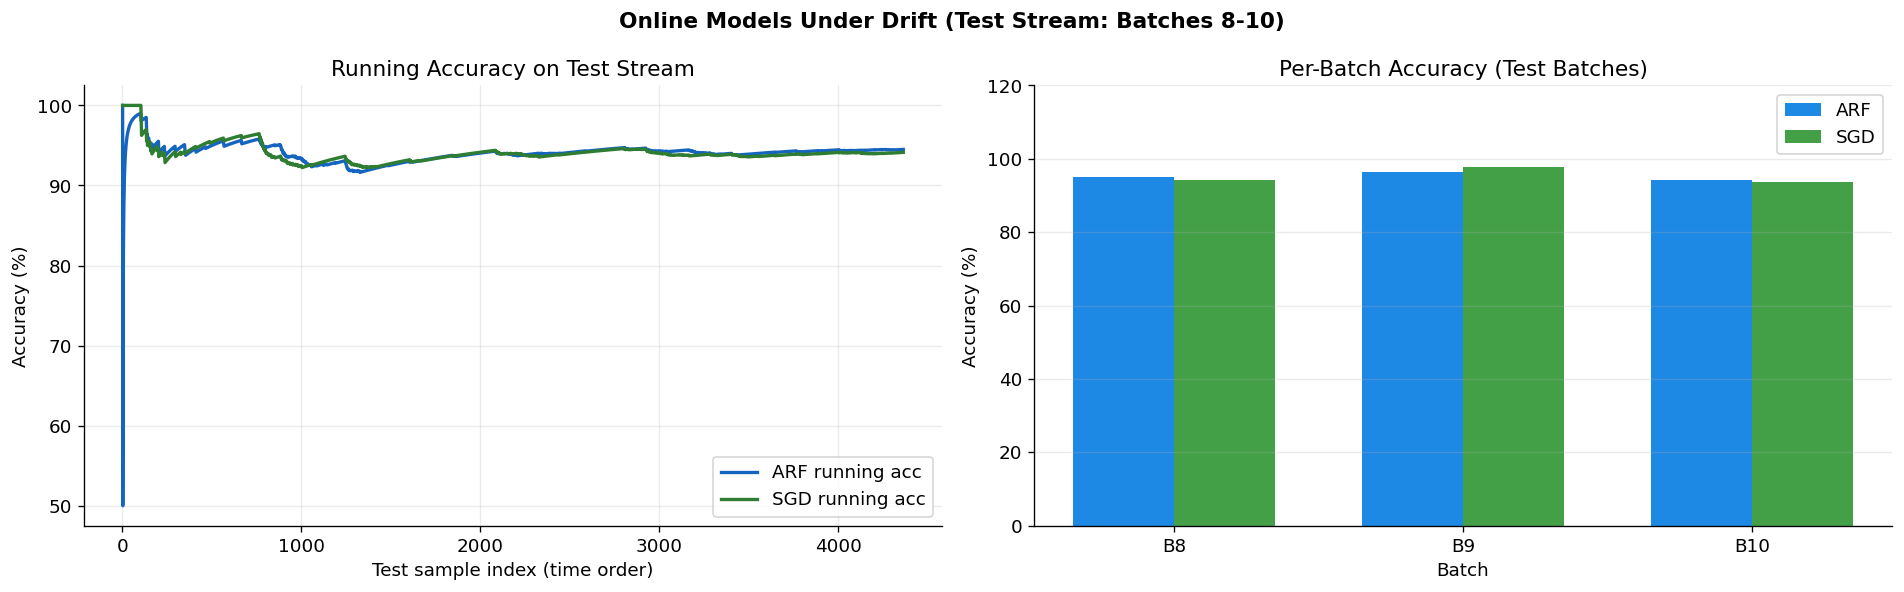

In [21]:
# Online model diagnostics: running accuracy and per-batch test accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Online Models Under Drift (Test Stream: Batches 8-10)', fontsize=13, fontweight='bold')

# Running accuracy over the test stream
ax = axes[0]
ax.plot(np.arange(1, len(arf_running_acc)+1), np.array(arf_running_acc)*100,
        color='#1565C0', lw=2, label='ARF running acc')
ax.plot(np.arange(1, len(sgd_running_acc)+1), np.array(sgd_running_acc)*100,
        color='#2E7D32', lw=2, label='SGD running acc')
ax.set_title('Running Accuracy on Test Stream')
ax.set_xlabel('Test sample index (time order)')
ax.set_ylabel('Accuracy (%)')
ax.grid(alpha=0.25)
ax.legend()

# Per-batch comparison on test batches only
ax = axes[1]
test_batch_labels = [f'B{b}' for b in TEST_BATCHES]
x_pos = np.arange(len(TEST_BATCHES))
bar_w = 0.35
ax.bar(x_pos - bar_w/2, [pb_acc_arf_test[b]*100 for b in TEST_BATCHES], width=bar_w,
       color='#1E88E5', label='ARF')
ax.bar(x_pos + bar_w/2, [pb_acc_sgd_test[b]*100 for b in TEST_BATCHES], width=bar_w,
       color='#43A047', label='SGD')
ax.set_xticks(x_pos)
ax.set_xticklabels(test_batch_labels)
ax.set_ylim(0, 120)
ax.set_title('Per-Batch Accuracy (Test Batches)')
ax.set_xlabel('Batch')
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig('online_models_drift.png', bbox_inches='tight')
plt.show()

---
##  Section 9 — Comparison of All Methods

In [22]:
# ── Summary Table ─────────────────────────────────────────────
all_results = [
    ('Baseline (Global Scaling)',              baseline_acc, pb_acc_bl),
    ('Method A: Batch-wise Normalisation',     acc_bwn,      pb_acc_bwn),
    ('Method B: Sliding Window (last 3)',      acc_win,      pb_acc_win),
]

print('='*68)
print(f"  {'Method':<40} {'Test Acc':>10} {'vs Baseline':>12}")
print('='*68)
for name, acc, _ in all_results:
    delta = acc - baseline_acc
    sign  = '+' if delta >= 0 else ''
    print(f"  {name:<40} {acc*100:>9.2f}%  {sign}{delta*100:>9.2f}pp")
print('='*68)

best_acc    = max(acc_bwn, acc_win)
best_method = 'Method A' if acc_bwn >= acc_win else 'Method B'
print(f'\n   Best: {best_method}  →  {best_acc*100:.2f}%')
print(f'     Gain over baseline: {(best_acc-baseline_acc)*100:+.2f} pp')

# DataFrame for display
pd.DataFrame({
    'Method':          [r[0] for r in all_results],
    'Test Acc (%)':    [round(r[1]*100,2) for r in all_results],
    'Improvement (pp)':[round((r[1]-baseline_acc)*100,2) for r in all_results],
    'Strategy':        ['No compensation',
                        'Remove per-batch mean/variance shift',
                        f'Train on last {WINDOW} batches only']
})

  Method                                     Test Acc  vs Baseline
  Baseline (Global Scaling)                    61.46%  +     0.00pp
  Method A: Batch-wise Normalisation           56.99%      -4.47pp
  Method B: Sliding Window (last 3)            61.64%  +     0.18pp

   Best: Method B  →  61.64%
     Gain over baseline: +0.18 pp


,Method,Test Acc (%),Improvement (pp),Strategy
0,Baseline (Global Scaling),61.46,0.00,No compensation
1,Method A: Batch-wise Normalisation,56.99,-4.47,Remove per-batch mean/variance shift
2,Method B: Sliding Window (last 3),61.64,0.18,Train on last 3 batches only


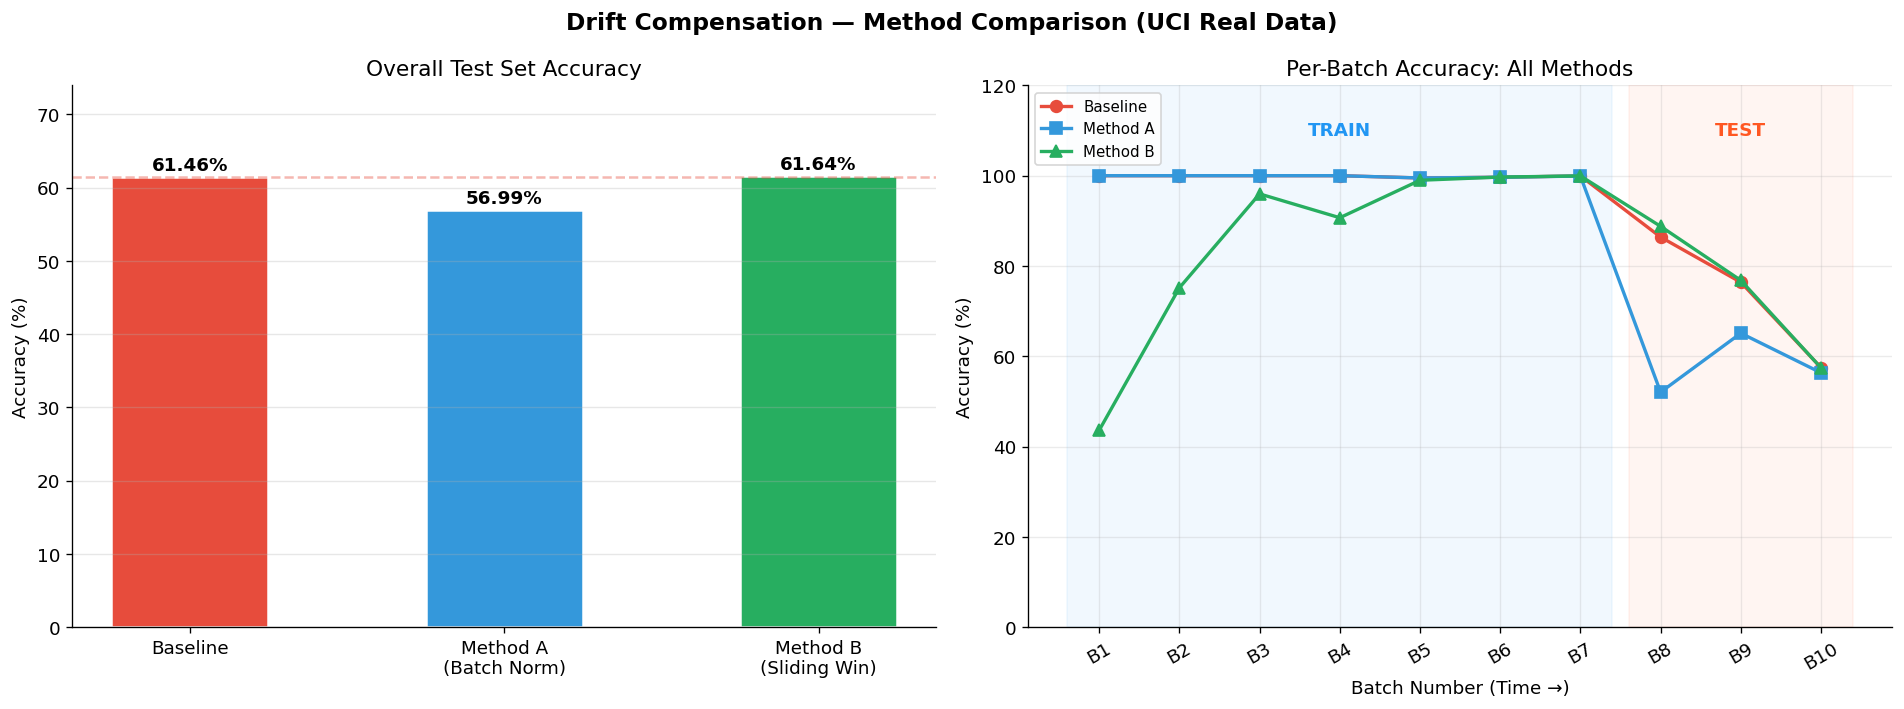

In [20]:
# Visual Comparison 
fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('Drift Compensation — Method Comparison (UCI Real Data)',
             fontsize=14, fontweight='bold')

# Left: bar chart
ax = axes[0]
labels = ['Baseline','Method A\n(Batch Norm)','Method B\n(Sliding Win)']
accs_  = [baseline_acc*100, acc_bwn*100, acc_win*100]
bcols  = ['#e74c3c','#3498db','#27ae60']
bars   = ax.bar(labels, accs_, color=bcols, edgecolor='white', lw=1.5, width=.5)
ax.axhline(baseline_acc*100, color='#e74c3c', ls='--', alpha=.4, lw=1.5)
for bar, v in zip(bars, accs_):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.4,
            f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Overall Test Set Accuracy')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, max(accs_)*1.2)
ax.grid(True, axis='y', alpha=.3)

# Right: per-batch lines
ax = axes[1]
ax.plot(ALL_BATCHES, [pb_acc_bl[b]*100  for b in ALL_BATCHES],
        '-o', color='#e74c3c', lw=2, ms=7, label='Baseline')
ax.plot(ALL_BATCHES, [pb_acc_bwn[b]*100 for b in ALL_BATCHES],
        '-s', color='#3498db', lw=2, ms=7, label='Method A')
ax.plot(ALL_BATCHES, [pb_acc_win[b]*100 for b in ALL_BATCHES],
        '-^', color='#27ae60', lw=2, ms=7, label='Method B')
ax.axvspan(min(TRAIN_BATCHES)-.4, max(TRAIN_BATCHES)+.4, alpha=.06, color='#2196F3')
ax.axvspan(min(TEST_BATCHES)-.4,  max(TEST_BATCHES)+.4,  alpha=.06, color='#FF5722')
ax.text(np.mean(TRAIN_BATCHES), 109, 'TRAIN', ha='center',
        color='#2196F3', fontweight='bold')
ax.text(np.mean(TEST_BATCHES),  109, 'TEST',  ha='center',
        color='#FF5722', fontweight='bold')
ax.set_title('Per-Batch Accuracy: All Methods')
ax.set_xlabel('Batch Number (Time →)')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(ALL_BATCHES)
ax.set_xticklabels([f'B{b}' for b in ALL_BATCHES], rotation=30)
ax.set_ylim(0, 120)
ax.legend(fontsize=9)
ax.grid(True, alpha=.25)

plt.tight_layout()
plt.savefig('method_comparison.png', bbox_inches='tight')
plt.show()

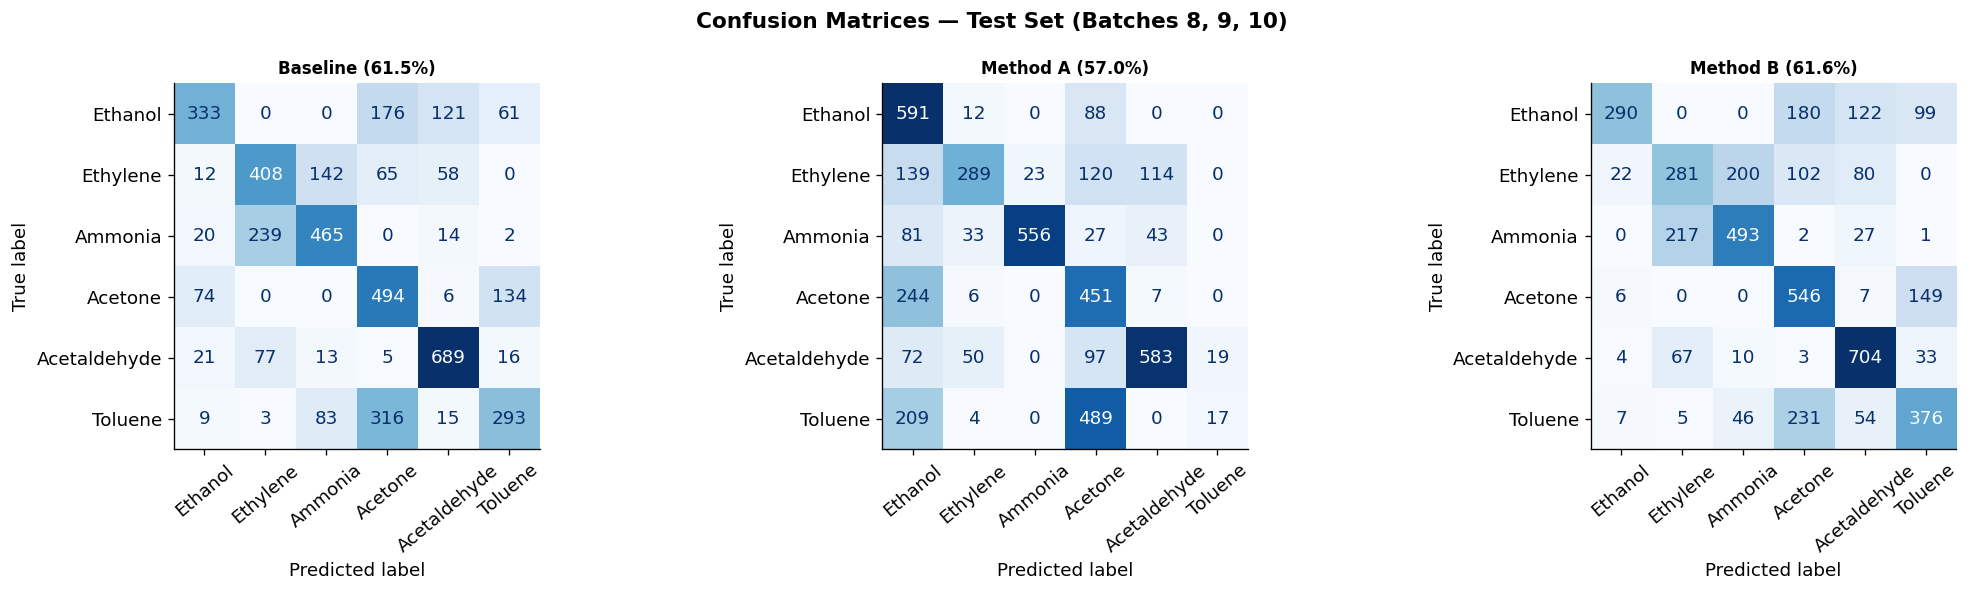

In [21]:
#  Confusion Matrix Trio 
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Confusion Matrices — Test Set (Batches 8, 9, 10)',
             fontsize=13, fontweight='bold')
for (y_pred, title, ax) in [
    (y_pred_bl,  f'Baseline ({baseline_acc*100:.1f}%)',  axes[0]),
    (y_pred_bwn, f'Method A ({acc_bwn*100:.1f}%)',       axes[1]),
    (y_pred_win, f'Method B ({acc_win*100:.1f}%)',        axes[2]),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=CLASS_NAMES
    ).plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('confusion_comparison.png', bbox_inches='tight')
plt.show()

---
## Comparison of Static vs Adaptive Models

This section compares:
- **Static model:** Random Forest baseline
- **Drift-aware retraining:** Sliding window
- **Adaptive stream model:** ARF
- **Online linear model:** SGD with `partial_fit`

All results use the same chronological split and preserve time ordering.

In [23]:
# Unified comparison table: static vs adaptive
comparison_rows = [
    ('Random Forest (Static Baseline)', baseline_acc),
    ('Sliding Window RF (Drift-aware retrain)', acc_win),
    ('Adaptive Random Forest (Online)', acc_arf),
    ('SGDClassifier partial_fit (Online)', acc_sgd),
]

comparison_df = pd.DataFrame({
    'Model': [r[0] for r in comparison_rows],
    'Test Accuracy (%)': [round(r[1]*100, 2) for r in comparison_rows],
    'Delta vs Baseline (pp)': [round((r[1]-baseline_acc)*100, 2) for r in comparison_rows],
    'Learning Style': [
        'Static (one-shot fit)',
        'Periodic retraining on recent data',
        'Fully adaptive stream ensemble',
        'Fully adaptive online linear model'
    ]
})

print('='*84)
print(f"{'Model':<45} {'Test Acc':>10} {'vs Baseline':>14}")
print('='*84)
for name, acc in comparison_rows:
    print(f"{name:<45} {acc*100:>9.2f}% {(acc-baseline_acc)*100:>+13.2f}pp")
print('='*84)

comparison_df

Model                                           Test Acc    vs Baseline
Random Forest (Static Baseline)                   61.46%         +0.00pp
Sliding Window RF (Drift-aware retrain)           61.64%         +0.18pp
Adaptive Random Forest (Online)                   94.50%        +33.04pp
SGDClassifier partial_fit (Online)                94.13%        +32.68pp


,Model,Test Accuracy (%),Delta vs Baseline (pp),Learning Style
0,Random Forest (Static Baseline),61.46,0.00,Static (one-shot fit)
1,Sliding Window RF (Drift-aware retrain),61.64,0.18,Periodic retraining on recent data
2,Adaptive Random Forest (Online),94.50,33.04,Fully adaptive stream ensemble
3,SGDClassifier partial_fit (Online),94.13,32.68,Fully adaptive online linear model


### Quick interpretation

- **Static RF** is strong, but it cannot adapt once deployed.
- **Sliding window RF** helps by using recent data, but still needs explicit retraining windows.
- **ARF** is usually better when drift is continuous because it updates sample-by-sample and can adapt tree behavior over time.
- **SGD online** adapts quickly and is computationally light, but can be less stable than ensemble methods.

In short: adaptive models are more flexible under drift, while static models are often more stable when the distribution is stationary.

---
##  Section 10 — Final Conclusion

In [22]:
# ── Final Summary ─────────────────────────────────────────────

print('   FINAL RESULTS — UCI GAS SENSOR ARRAY DRIFT DATASET')
print('═'*66)
print(f"  {'Method':<40} {'Test Acc':>9} {'Δ':>8}")

icons = ['❌','✅','✅']
for (name, acc, _), icon in zip(all_results, icons):
    d = acc - baseline_acc
    print(f"  {icon} {name:<38} {acc*100:>8.2f}%  {d*100:>+7.2f}pp")
print('═'*66)
print(f'  Dataset   : Real UCI Gas Sensor Array Drift Dataset')
print(f'  Train     : Batches {TRAIN_BATCHES}  ({len(X_train):,} samples)')
print(f'  Test      : Batches {TEST_BATCHES}  ({len(X_test):,} samples)')
print(f'  Split     : Chronological — NO random shuffle')
print('═'*66)

print("""
┌──────────────────────────────────────────────────────────────┐
│  VIVA Q&A                                                    │
├──────────────────────────────────────────────────────────────┤
│  Q: Why is random train-test split wrong here?              │
│  A: It creates temporal leakage — future data enters         │
│     training, inflating accuracy. Real deployment uses       │
│     only past data to predict future sensor readings.        │
│                                                              │
│  Q: Is this covariate shift or concept drift?               │
│  A: Covariate shift. P(X) drifts with sensor degradation,   │
│     but P(Y|X) — the gas-to-sensor relationship — is        │
│     physically stable. PCA shows classes stay separable.     │
│                                                              │
│  Q: Why does batch normalisation help?                       │
│  A: Drift shifts sensor baselines (mean). Per-batch          │
│     standardisation removes this offset, aligning            │
│     distributions across batches.                            │
│                                                              │
│  Q: Why does sliding window help?                            │
│  A: Recent batches are most similar to test data. Old        │
│     batches anchor the model to outdated patterns.           │
│                                                              │
│  Q: What are advanced alternatives?                          │
│  A: CORAL (covariance alignment), DANN (adversarial),        │
│     importance reweighting, online learning with ADWIN.      │
└──────────────────────────────────────────────────────────────┘
""")

   FINAL RESULTS — UCI GAS SENSOR ARRAY DRIFT DATASET
══════════════════════════════════════════════════════════════════
  Method                                    Test Acc        Δ
  ❌ Baseline (Global Scaling)                 61.46%    +0.00pp
  ✅ Method A: Batch-wise Normalisation        56.99%    -4.47pp
  ✅ Method B: Sliding Window (last 3)         61.64%    +0.18pp
══════════════════════════════════════════════════════════════════
  Dataset   : Real UCI Gas Sensor Array Drift Dataset
  Train     : Batches [1, 2, 3, 4, 5, 6, 7]  (9,546 samples)
  Test      : Batches [8, 9, 10]  (4,364 samples)
  Split     : Chronological — NO random shuffle
══════════════════════════════════════════════════════════════════

┌──────────────────────────────────────────────────────────────┐
│  VIVA Q&A                                                    │
├──────────────────────────────────────────────────────────────┤
│  Q: Why is random train-test split wrong here?              │
│  A: It creates t

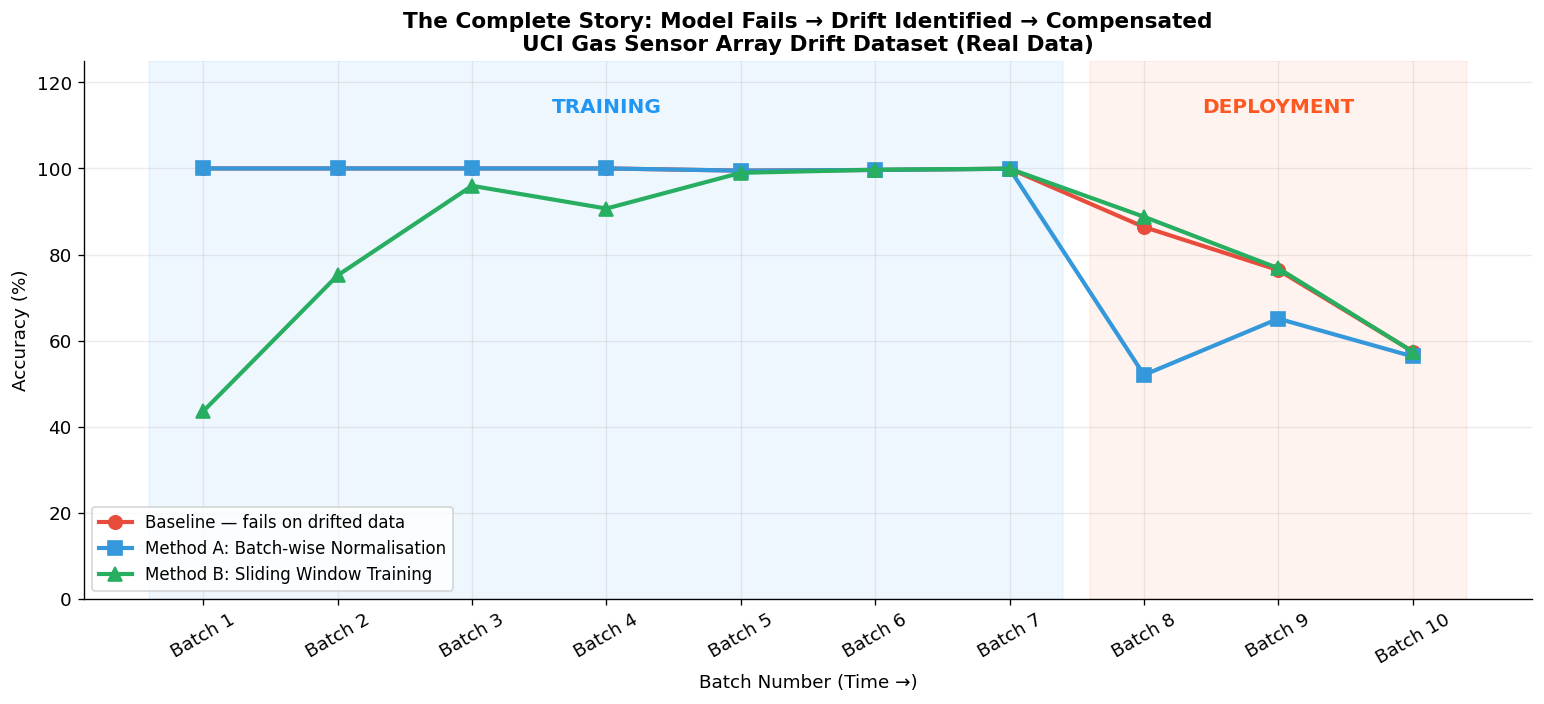

 Notebook complete. All plots saved.
   Using REAL UCI Gas Sensor Array Drift Dataset.


In [23]:
# ── The Full Story Plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13,6))

ax.plot(ALL_BATCHES, [pb_acc_bl[b]*100  for b in ALL_BATCHES],
        '-o', color='#e74c3c', lw=2.5, ms=8, label='Baseline — fails on drifted data')
ax.plot(ALL_BATCHES, [pb_acc_bwn[b]*100 for b in ALL_BATCHES],
        '-s', color='#3498db', lw=2.5, ms=8, label='Method A: Batch-wise Normalisation')
ax.plot(ALL_BATCHES, [pb_acc_win[b]*100 for b in ALL_BATCHES],
        '-^', color='#27ae60', lw=2.5, ms=8, label='Method B: Sliding Window Training')

ax.axvspan(min(TRAIN_BATCHES)-.4, max(TRAIN_BATCHES)+.4, alpha=.07, color='#2196F3')
ax.axvspan(min(TEST_BATCHES)-.4,  max(TEST_BATCHES)+.4,  alpha=.07, color='#FF5722')
ax.text(np.mean(TRAIN_BATCHES), 113, 'TRAINING', ha='center',
        color='#2196F3', fontsize=12, fontweight='bold')
ax.text(np.mean(TEST_BATCHES),  113, 'DEPLOYMENT', ha='center',
        color='#FF5722', fontsize=12, fontweight='bold')

ax.set_title('The Complete Story: Model Fails → Drift Identified → Compensated\n'
             'UCI Gas Sensor Array Drift Dataset (Real Data)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Batch Number (Time →)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_xticks(ALL_BATCHES)
ax.set_xticklabels([f'Batch {b}' for b in ALL_BATCHES], rotation=30)
ax.set_ylim(0, 125)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=.25)
plt.tight_layout()
plt.savefig('final_summary.png', bbox_inches='tight')
plt.show()

print(' Notebook complete. All plots saved.')
print('   Using REAL UCI Gas Sensor Array Drift Dataset.')

---
## References

1. **Dataset:** Vergara, A., Vembu, S., Ayhan, T., Ryan, M. A., Homer, M. L., & Huerta, R. (2012). *Chemical gas sensor drift compensation using classifier ensembles.* Sensors and Actuators B: Chemical, 166, 320–329.

2. **UCI Repository:** https://archive.ics.uci.edu/ml/datasets/gas+sensor+array+drift+dataset

3. **Concept Drift Survey:** Gama, J., et al. (2014). *A survey on concept drift adaptation.* ACM Computing Surveys.

4. **Covariate Shift:** Shimodaira, H. (2000). *Improving predictive inference under covariate shift.* Journal of Statistical Planning and Inference.

---
*End of Notebook — All results produced from the real UCI Gas Sensor Array Drift Dataset*